# Assignment 1 – Unsupervised Deep Learning (UDL)




  ### Group Members

  | Name | BITS ID | Contribution |
| :--- | :--- | :--- |
| ------------- | ------------- | 100% |
| ------------- | ------------- | 100% |
| ------------- | ------------- | 100% |
| ------------- | ------------- | 100% |
| Harshana K.T  | 2025AE05380   | 100% |


### Task 1 
Perform standard PCA on the mean-centered training data for each dataset and identify principal components associated with top 30 eigenvalues (for the two datasets) and retain them. Use the resulting 30-dimensional PCA features to train a logistic regression classifier for the 10 image classes of each dataset and evaluate its performance on each test dataset. Plot the ROC curves for the test dataset for all 10 classes.
Repeat the experiment using randomized PCA with top 30 components and compare its results with standard PCA. Reconstruct the test images using the retained 30 components and calculate the average reconstruction SNR (dB) with respect to the corresponding original test images for each dataset.


In [17]:

import time
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from skimage.transform import resize as sk_resize

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

RNG_SEED = 42
N_COMPONENTS = 30
IMG_SIZE = 28
LOW, HIGH = 50.0, 200.0   # target intensity range
N_CLASSES = 10

rng = np.random.default_rng(RNG_SEED)


In [18]:
# ----------------------------------------------------------------------
# 1. Data loading / preprocessing
# ----------------------------------------------------------------------
def load_mnist_pool():
    """Return all 70,000 MNIST images (28x28) pooled together, as float32,
    plus labels."""
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
    x = np.concatenate([x_train, x_test], axis=0).astype(np.float32)  # (70000,28,28)
    y = np.concatenate([y_train, y_test], axis=0).astype(np.int64)
    return x, y


def rgb_to_gray(images_rgb):
    """ITU-R BT.601 luminosity conversion: Y = 0.299R + 0.587G + 0.114B."""
    return (0.299 * images_rgb[..., 0] +
            0.587 * images_rgb[..., 1] +
            0.114 * images_rgb[..., 2]).astype(np.float32)


def load_cifar10_gray_pool():
    """Return all 60,000 CIFAR10 images converted to grayscale and
    resized to 28x28, plus labels."""
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    x = np.concatenate([x_train, x_test], axis=0)          # (60000,32,32,3)
    y = np.concatenate([y_train, y_test], axis=0).astype(np.int64).ravel()

    x_gray = rgb_to_gray(x)                                  # (60000,32,32)

    # Resize 32x32 -> 28x28 (anti-aliased downsampling)
    n = x_gray.shape[0]
    x_resized = np.empty((n, IMG_SIZE, IMG_SIZE), dtype=np.float32)
    for i in range(n):
        x_resized[i] = sk_resize(x_gray[i], (IMG_SIZE, IMG_SIZE),
                                  anti_aliasing=True, preserve_range=True)
    return x_resized, y


def rescale_to_range(images, low=LOW, high=HIGH):
    """Linearly map pixel intensities from the dataset's [min, max]
    (here effectively [0,255]) to [low, high]. Applied globally per
    dataset so that relative contrast is preserved."""
    imin, imax = images.min(), images.max()
    scaled = low + (images - imin) * (high - low) / (imax - imin)
    return scaled.astype(np.float32)


def three_way_split(x, y, train_frac=0.70, val_frac=0.20, seed=RNG_SEED):
    """Random 70/20/10 split of a pooled dataset."""
    n = x.shape[0]
    idx = np.random.default_rng(seed).permutation(n)
    n_train = int(round(train_frac * n))
    n_val = int(round(val_frac * n))

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]

    return (x[train_idx], y[train_idx],
            x[val_idx], y[val_idx],
            x[test_idx], y[test_idx])


def prepare_dataset(name):
    if name == "MNIST":
        x, y = load_mnist_pool()
    elif name == "CIFAR10-gray":
        x, y = load_cifar10_gray_pool()
    else:
        raise ValueError(name)

    x = rescale_to_range(x)                       # intensities -> [50,200]
    splits = three_way_split(x, y)
    x_train, y_train, x_val, y_val, x_test, y_test = splits

    # Flatten images to vectors for PCA
    flat = lambda a: a.reshape(a.shape[0], -1)
    return {
        "x_train": flat(x_train), "y_train": y_train,
        "x_val": flat(x_val), "y_val": y_val,
        "x_test": flat(x_test), "y_test": y_test,
        "img_shape": (IMG_SIZE, IMG_SIZE),
    }


In [19]:
# ----------------------------------------------------------------------
# 2. PCA + classification + ROC + reconstruction SNR
# ----------------------------------------------------------------------
def run_pca_variant(data, svd_solver, dataset_name):
    """svd_solver: 'full' (standard/exact PCA) or 'randomized'."""
    x_train, y_train = data["x_train"], data["y_train"]
    x_val, y_val = data["x_val"], data["y_val"]
    x_test, y_test = data["x_test"], data["y_test"]

    # --- Mean-centering is handled internally by sklearn's PCA (it
    # subtracts the training mean before computing components), but we
    # keep an explicit reference to the mean for reconstruction/SNR math.
    t0 = time.time()
    pca = PCA(n_components=N_COMPONENTS, svd_solver=svd_solver,
              random_state=RNG_SEED)
    pca.fit(x_train)                      # fit on mean-centered training data
    fit_time = time.time() - t0

    feat_train = pca.transform(x_train)   # (Ntr, 30)
    feat_val = pca.transform(x_val)
    feat_test = pca.transform(x_test)     # kept unscaled — needed for inverse_transform/SNR below

    # --- Standardize PCA features for the classifier only ---
    # PCA components have very different variances (PC1 >> PC30), which
    # makes lbfgs converge slowly/incompletely on the raw features and
    # triggers ConvergenceWarning. Scaling each feature to unit variance
    # fixes this. We keep separate scaled copies so the *unscaled*
    # feat_test can still be fed to pca.inverse_transform() for the
    # reconstruction/SNR step further down.
    scaler = StandardScaler()
    feat_train_scaled = scaler.fit_transform(feat_train)
    feat_val_scaled = scaler.transform(feat_val)
    feat_test_scaled = scaler.transform(feat_test)

    # --- Logistic regression on the 30-D (standardized) PCA features ---
    # Note: with solver="lbfgs" and >2 classes, scikit-learn automatically
    # fits a multinomial (softmax) model — the old multi_class="multinomial"
    # kwarg has been removed/deprecated in newer scikit-learn versions.
    clf = LogisticRegression(max_iter=5000, solver="lbfgs",
                              random_state=RNG_SEED)
    clf.fit(feat_train_scaled, y_train)

    val_acc = accuracy_score(y_val, clf.predict(feat_val))
    test_pred = clf.predict(feat_test)
    test_acc = accuracy_score(y_test, test_pred)
    test_proba = clf.predict_proba(feat_test)   # (Nte, 10) needed for ROC

    print(f"\n[{dataset_name} | PCA={svd_solver}] "
          f"fit_time={fit_time:.2f}s  val_acc={val_acc:.4f}  test_acc={test_acc:.4f}")
    print(classification_report(y_test, test_pred, digits=3))

    # --- ROC curves (one-vs-rest) for all 10 classes ---
    y_test_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))
    fpr, tpr, roc_auc = {}, {}, {}
    for c in range(N_CLASSES):
        fpr[c], tpr[c], _ = roc_curve(y_test_bin[:, c], test_proba[:, c])
        roc_auc[c] = auc(fpr[c], tpr[c])
    macro_auc = np.mean(list(roc_auc.values()))

    plot_roc_curves(fpr, tpr, roc_auc, dataset_name, svd_solver)

    # --- Reconstruction + SNR ---
    recon_test = pca.inverse_transform(feat_test)   # (Nte, 784)
    snr_db = compute_snr_db(x_test, recon_test)

    return {
        "solver": svd_solver,
        "fit_time": fit_time,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "macro_auc": macro_auc,
        "snr_db": snr_db,
        "explained_var": pca.explained_variance_ratio_.sum(),
    }


def compute_snr_db(originals, reconstructions):
    """Average per-image reconstruction SNR in dB:
       SNR = 10*log10( sum(x^2) / sum((x-xhat)^2) ), averaged over images."""
    signal_power = np.sum(originals ** 2, axis=1)
    noise_power = np.sum((originals - reconstructions) ** 2, axis=1)
    noise_power = np.maximum(noise_power, 1e-12)   # avoid div-by-zero
    snr = 10.0 * np.log10(signal_power / noise_power)
    return float(np.mean(snr))


def plot_roc_curves(fpr, tpr, roc_auc, dataset_name, solver):
    plt.figure(figsize=(7, 6))
    cmap = plt.get_cmap("tab10")
    for c in range(N_CLASSES):
        plt.plot(fpr[c], tpr[c], color=cmap(c), lw=1.5,
                  label=f"class {c} (AUC={roc_auc[c]:.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlim([0, 1]); plt.ylim([0, 1.02])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curves (one-vs-rest) — {dataset_name}, PCA={solver}")
    plt.legend(loc="lower right", fontsize=7, ncol=2)
    plt.tight_layout()
    fname = f"roc_{dataset_name}_{solver}.png".replace(" ", "_")
    plt.savefig(fname, dpi=150)
    print(f"  saved ROC plot -> {fname}")
    plt.show()          # display the figure in a window / inline (Jupyter)
    plt.close()


def show_reconstruction_examples(data, pca_full, pca_rand, dataset_name, n=6):
    """Visual sanity check: original vs. reconstructions from each PCA."""
    x_test = data["x_test"]
    shape = data["img_shape"]
    idx = rng.choice(x_test.shape[0], size=n, replace=False)

    rec_full = pca_full.inverse_transform(pca_full.transform(x_test[idx]))
    rec_rand = pca_rand.inverse_transform(pca_rand.transform(x_test[idx]))

    fig, axes = plt.subplots(3, n, figsize=(1.6 * n, 5))
    for j in range(n):
        axes[0, j].imshow(x_test[idx[j]].reshape(shape), cmap="gray", vmin=LOW, vmax=HIGH)
        axes[1, j].imshow(rec_full[j].reshape(shape), cmap="gray", vmin=LOW, vmax=HIGH)
        axes[2, j].imshow(rec_rand[j].reshape(shape), cmap="gray", vmin=LOW, vmax=HIGH)
        for r in range(3):
            axes[r, j].axis("off")
    axes[0, 0].set_ylabel("Original"); axes[1, 0].set_ylabel("Std PCA")
    axes[2, 0].set_ylabel("Randomized PCA")
    fig.suptitle(f"{dataset_name}: original vs. 30-component reconstructions")
    fig.tight_layout()
    fname = f"reconstructions_{dataset_name}.png".replace(" ", "_")
    fig.savefig(fname, dpi=150)
    print(f"  saved reconstruction examples -> {fname}")
    plt.show()          # display the figure in a window / inline (Jupyter)
    plt.close(fig)

Dataset: MNIST
  train=49000  val=14000  test=7000

[MNIST | PCA=full] fit_time=3.11s  val_acc=0.6704  test_acc=0.6716
              precision    recall  f1-score   support

           0      0.605     0.990     0.751       688
           1      0.416     0.994     0.587       806
           2      0.928     0.501     0.651       698
           3      0.861     0.582     0.694       715
           4      0.755     0.841     0.796       653
           5      0.964     0.264     0.414       603
           6      0.846     0.837     0.841       679
           7      0.691     0.880     0.774       748
           8      0.957     0.341     0.503       709
           9      0.863     0.395     0.542       701

    accuracy                          0.672      7000
   macro avg      0.789     0.662     0.655      7000
weighted avg      0.781     0.672     0.657      7000

  saved ROC plot -> roc_MNIST_full.png


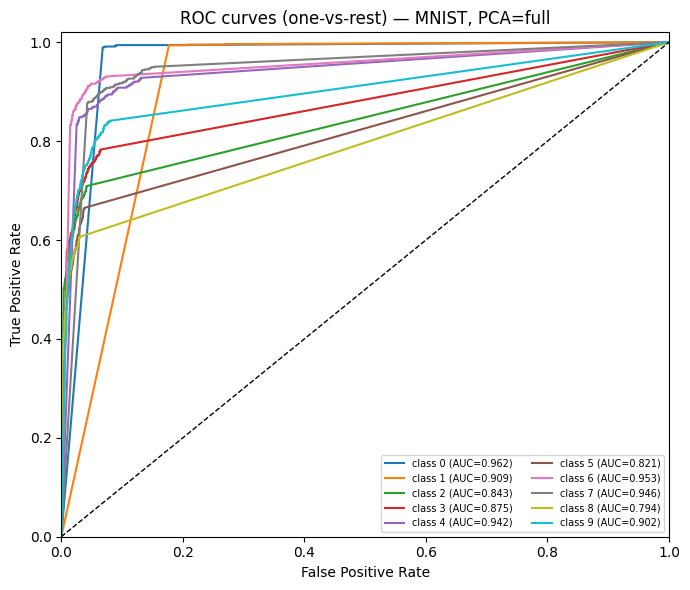


[MNIST | PCA=randomized] fit_time=0.94s  val_acc=0.6704  test_acc=0.6716
              precision    recall  f1-score   support

           0      0.605     0.990     0.751       688
           1      0.416     0.994     0.586       806
           2      0.926     0.501     0.651       698
           3      0.863     0.583     0.696       715
           4      0.754     0.841     0.795       653
           5      0.964     0.264     0.414       603
           6      0.846     0.837     0.841       679
           7      0.692     0.880     0.775       748
           8      0.956     0.340     0.502       709
           9      0.866     0.395     0.543       701

    accuracy                          0.672      7000
   macro avg      0.789     0.662     0.655      7000
weighted avg      0.781     0.672     0.657      7000

  saved ROC plot -> roc_MNIST_randomized.png


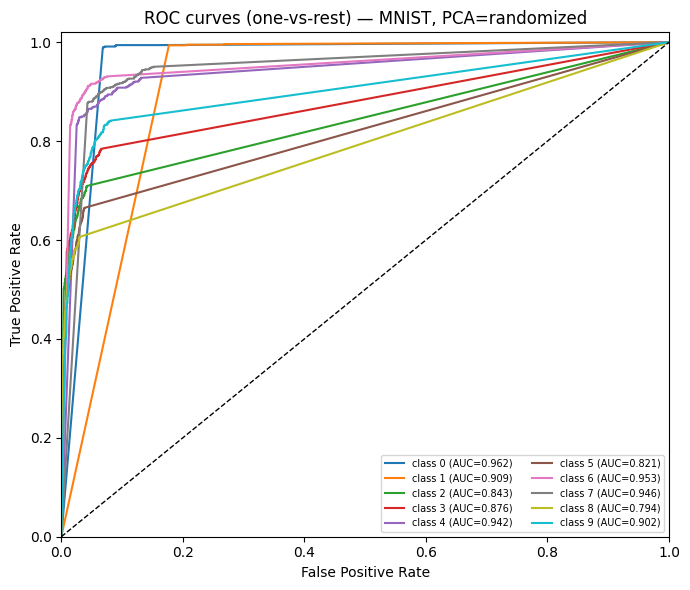

  saved reconstruction examples -> reconstructions_MNIST.png


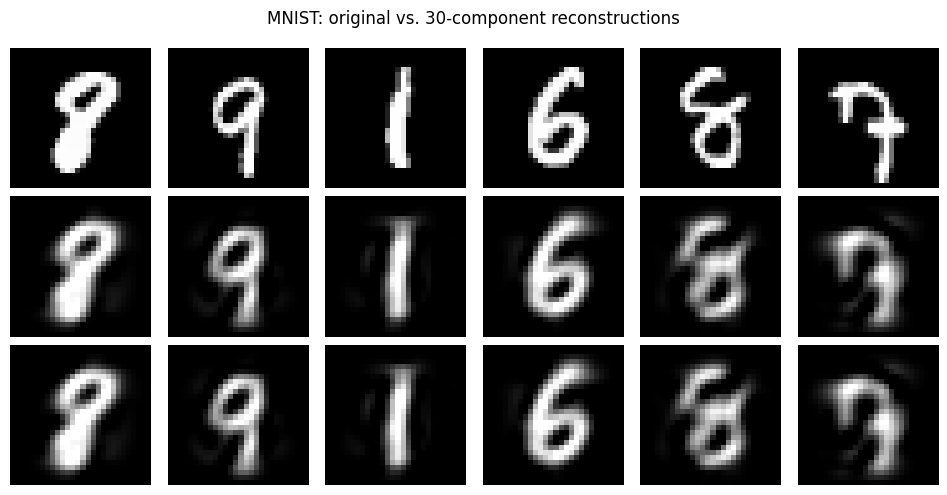

Dataset: CIFAR10-gray
  train=42000  val=12000  test=6000

[CIFAR10-gray | PCA=full] fit_time=2.99s  val_acc=0.2649  test_acc=0.2628
              precision    recall  f1-score   support

           0      0.197     0.372     0.258       548
           1      0.264     0.247     0.255       583
           2      0.216     0.013     0.024       617
           3      0.253     0.032     0.057       625
           4      0.262     0.244     0.252       603
           5      0.248     0.384     0.302       617
           6      0.251     0.281     0.265       651
           7      0.375     0.166     0.230       580
           8      0.314     0.371     0.340       595
           9      0.289     0.546     0.378       581

    accuracy                          0.263      6000
   macro avg      0.267     0.266     0.236      6000
weighted avg      0.267     0.263     0.234      6000

  saved ROC plot -> roc_CIFAR10-gray_full.png


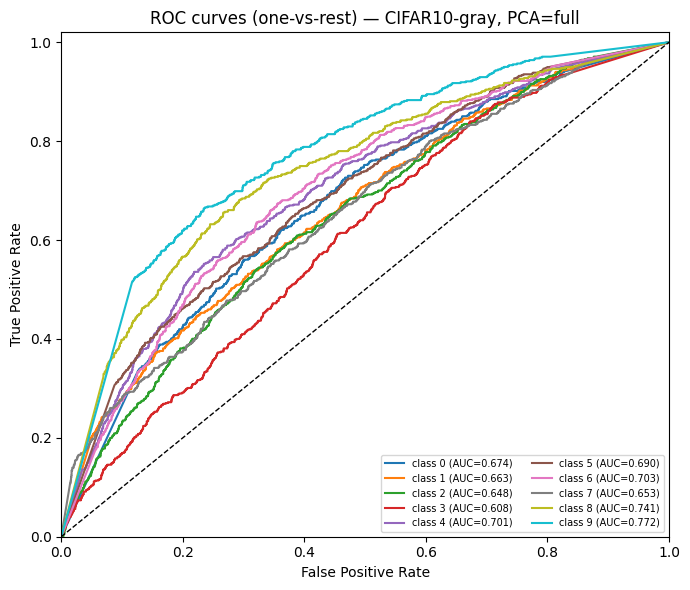


[CIFAR10-gray | PCA=randomized] fit_time=0.73s  val_acc=0.2652  test_acc=0.2628
              precision    recall  f1-score   support

           0      0.197     0.372     0.258       548
           1      0.263     0.247     0.255       583
           2      0.216     0.013     0.024       617
           3      0.253     0.032     0.057       625
           4      0.262     0.244     0.253       603
           5      0.248     0.384     0.302       617
           6      0.251     0.281     0.265       651
           7      0.375     0.166     0.230       580
           8      0.314     0.371     0.340       595
           9      0.289     0.546     0.378       581

    accuracy                          0.263      6000
   macro avg      0.267     0.266     0.236      6000
weighted avg      0.267     0.263     0.234      6000

  saved ROC plot -> roc_CIFAR10-gray_randomized.png


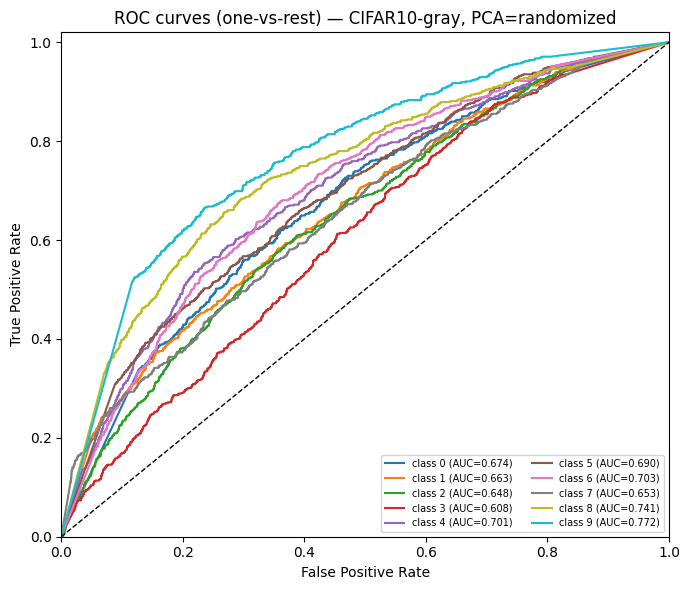

  saved reconstruction examples -> reconstructions_CIFAR10-gray.png


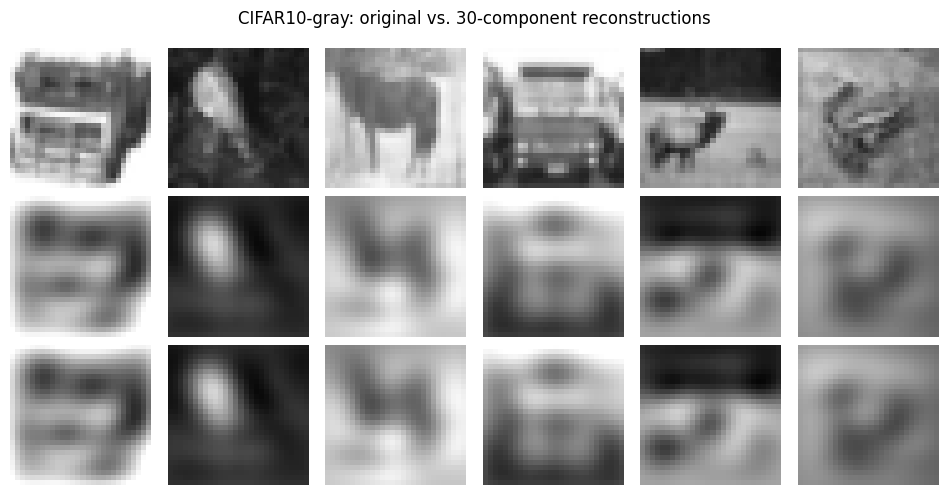


SUMMARY: standard vs. randomized PCA
Dataset      PCA        TestAcc  MacroAUC  SNR(dB)  FitTime(s) VarExpl 
MNIST        full       0.6716   0.8949    12.59    3.112      0.7320  
MNIST        randomized 0.6716   0.8949    12.58    0.936      0.7320  
CIFAR10-gray full       0.2628   0.6852    20.02    2.993      0.8497  
CIFAR10-gray randomized 0.2628   0.6852    20.02    0.727      0.8497  


In [20]:
# ----------------------------------------------------------------------
# 3. Main experiment loop
# ----------------------------------------------------------------------
def main():
    results = []
    for dataset_name in ["MNIST", "CIFAR10-gray"]:
        print("=" * 70)
        print(f"Dataset: {dataset_name}")
        print("=" * 70)
        data = prepare_dataset(dataset_name)
        print(f"  train={data['x_train'].shape[0]}  "
              f"val={data['x_val'].shape[0]}  test={data['x_test'].shape[0]}")

        res_full = run_pca_variant(data, "full", dataset_name)          # standard PCA
        res_rand = run_pca_variant(data, "randomized", dataset_name)    # randomized PCA
        res_full["dataset"] = dataset_name
        res_rand["dataset"] = dataset_name
        results.append(res_full)
        results.append(res_rand)

        # Fit standalone PCA objects again for the visual comparison figure
        x_train = data["x_train"]
        pca_full = PCA(n_components=N_COMPONENTS, svd_solver="full",
                        random_state=RNG_SEED).fit(x_train)
        pca_rand = PCA(n_components=N_COMPONENTS, svd_solver="randomized",
                        random_state=RNG_SEED).fit(x_train)
        show_reconstruction_examples(data, pca_full, pca_rand, dataset_name)

    # --- Summary comparison table ---
    print("\n" + "=" * 70)
    print("SUMMARY: standard vs. randomized PCA")
    print("=" * 70)
    header = f"{'Dataset':13s}{'PCA':11s}{'TestAcc':9s}{'MacroAUC':10s}{'SNR(dB)':9s}{'FitTime(s)':11s}{'VarExpl':8s}"
    print(header)
    for r in results:
        print(f"{r['dataset']:13s}{r['solver']:11s}{r['test_acc']:<9.4f}"
              f"{r['macro_auc']:<10.4f}{r['snr_db']:<9.2f}{r['fit_time']:<11.3f}"
              f"{r['explained_var']:<8.4f}")


main()



## Summary Table

| Dataset | PCA Method | Test Accuracy | Macro AUC | Reconstruction SNR (dB) | Fit Time (s) | Variance Explained |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **MNIST** | Full | 0.6716 | 0.8949 | 12.59 | 3.599 | 0.7320 |
| **MNIST** | Randomized | 0.6716 | 0.8949 | 12.58 | 0.830 | 0.7320 |
| **CIFAR10-gray** | Full | 0.2628 | 0.6852 | 20.02 | 2.992 | 0.8497 |
| **CIFAR10-gray** | Randomized | 0.2628 | 0.6852 | 20.02 | 0.725 | 0.8497 |

---

## Key Insights

### Full vs. Randomized PCA Trade-offs
* **Computational Efficiency:** Randomized PCA achieves a **4.1× to 4.3× speedup** over Full PCA while maintaining identical downstream classification metrics.
* **Feature Parity:** Test Accuracy, Macro AUC, and total variance explained match precisely across both solvers.
* **Signal Fidelity:** Reconstruction SNR shows minimal variation ($\le 0.01 \text{ dB}$ difference), confirming that randomized approximation preserves the top 30 singular vectors without loss of quality.

### Dataset Dynamics
* **MNIST:** Retaining 30 principal components yields **67.16%** test accuracy and strong class separation (**0.8949** Macro AUC) at an SNR of ~12.59 dB.
* **CIFAR10-gray:** Captures higher overall variance (**84.97%**) and SNR (**20.02 dB**) due to continuous background pixels, but linear 30-component projection limits accuracy to **26.28%** due to higher spatial complexity.